In [1]:
## imports
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import librosa.display
from wada_snr import wada_snr
import numpy as np

In [7]:
# define paths
real_audio_path = "/home/bs_thesis/datasets/OurDataset/SceneFake-Wild-Real/aud1032_dev3.wav"
fake_audio_path = "/home/bs_thesis/datasets/OurDataset/Ours_Fake/samples3/fake_aud1032_dev3.wav"

In [8]:
y_real, sr_real = librosa.load(real_audio_path, sr=None)
y_fake, sr_fake = librosa.load(fake_audio_path, sr=None)


#### Waveform

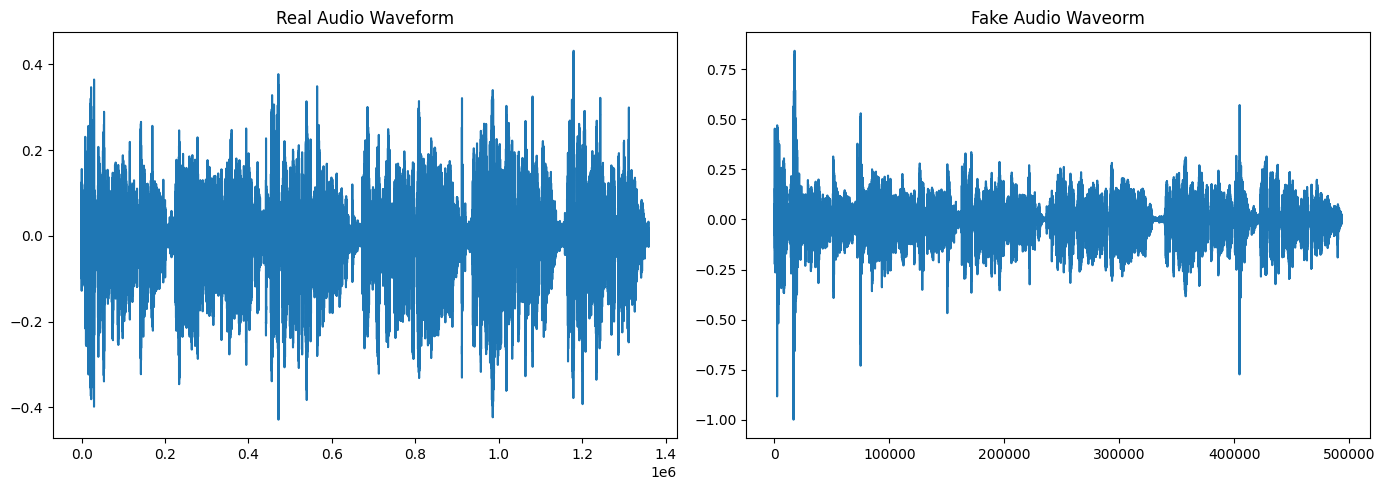

In [11]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(y_real)
plt.title("Real Audio Waveform")
plt.subplot(1,2,2)
plt.plot(y_fake)
plt.title("Fake Audio Waveorm")
plt.tight_layout()
plt.show()

#### spectrogram

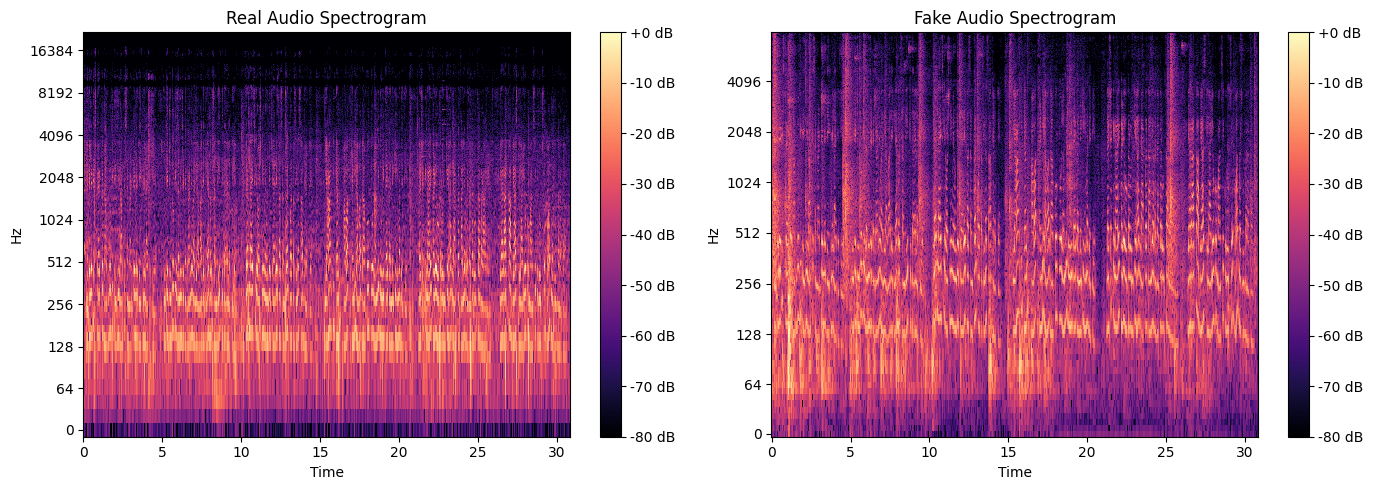

In [9]:
S_real = librosa.amplitude_to_db(np.abs(librosa.stft(y_real)), ref=np.max)
S_fake = librosa.amplitude_to_db(np.abs(librosa.stft(y_fake)), ref=np.max)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
librosa.display.specshow(S_real, sr=sr_real, x_axis="time", y_axis="log")
plt.title("Real Audio Spectrogram")
plt.colorbar(format="%+2.0f dB")
plt.subplot(1,2,2)
librosa.display.specshow(S_fake, sr=sr_fake, x_axis="time", y_axis="log")
plt.title("Fake Audio Spectrogram")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()

#### WADA-SNR

In [12]:

def compute_time_varying_snr(audio, sr, window_sec=2, hop_sec=1):

    window = int(window_sec * sr)
    hop = int(hop_sec * sr)

    snrs = []
    times = []

    for start in range(0, len(audio) - window, hop):

        segment = audio[start:start + window]

        snr = wada_snr(segment)

        snrs.append(snr)
        times.append((start + window/2) / sr)

    return np.array(times), np.array(snrs)

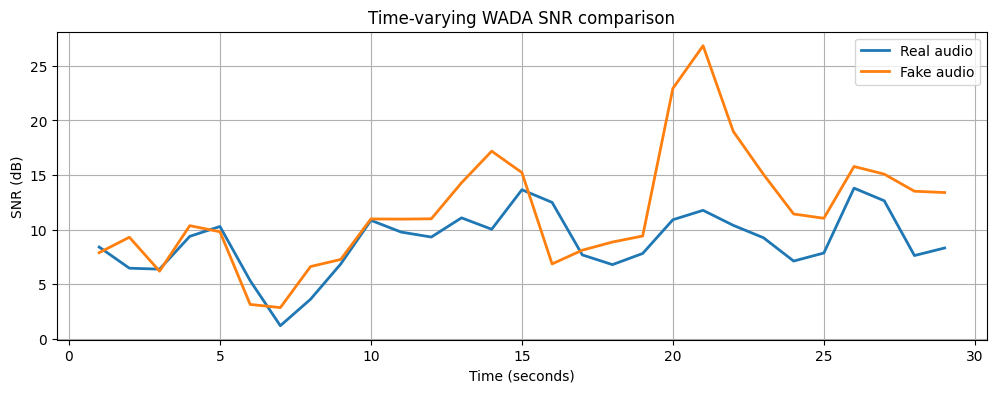

In [13]:

real_audio, sr1 = sf.read(real_audio_path)
fake_audio, sr2 = sf.read(fake_audio_path)

if real_audio.ndim > 1:
    real_audio = real_audio.mean(axis=1)

if fake_audio.ndim > 1:
    fake_audio = fake_audio.mean(axis=1)


# compute SNR curves
times_real, snr_real = compute_time_varying_snr(real_audio, sr1)
times_fake, snr_fake = compute_time_varying_snr(fake_audio, sr2)


# plot comparison
plt.figure(figsize=(12,4))

plt.plot(times_real, snr_real, label="Real audio", linewidth=2)
plt.plot(times_fake, snr_fake, label="Fake audio", linewidth=2)

plt.xlabel("Time (seconds)")
plt.ylabel("SNR (dB)")
plt.title("Time-varying WADA SNR comparison")
plt.legend()
plt.grid(True)

plt.show()